## 1. Import Libraries and Define Parameters

In this section, we define:

- Physical constants
- Sampling parameters
- Angle search space

These parameters are required for both CCV and MUSIC algorithms.

In [1]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Physical parameters
c = 343  # speed of sound in air (m/s)
d = 0.3  # sensors separation (m)

# sampling parameters
fs = 100000
ts = 1/fs

# angular spacing
angles = np.arange(-60, 60.1, 0.1)

# base frequency 
base_freq = 1200  # 1.2 kHz

## 2. Load Processed Signals

We load the MATLAB dataset containing the processed signals for different distances.

Each dataset has dimensions:

[samples, positions, measurements]

In [2]:
mat = sio.loadmat("processed_signals.mat")

data_1_20 = mat["data_1_20"]
data_2_20 = mat["data_2_20"]

data_1_30 = mat["data_1_30"]
data_2_30 = mat["data_2_30"]

data_1_40 = mat["data_1_40"]
data_2_40 = mat["data_2_40"]

data_1_50 = mat["data_1_50"]
data_2_50 = mat["data_2_50"]

## 3. CCV Algorithm (Cross-Correlation Vector)

This function implements the proposed CCV method:

Steps:
1. Compute FFT of both signals
2. Compute cross-spectrum
3. Apply inverse FFT
4. Normalize
5. Extract delay from correlation peak

In [3]:
def CCV(signal1, signal2, max_delay=40):
    # FFT
    S1 = np.fft.fft(signal1)
    S2 = np.fft.fft(signal2)
    ccv = S2 * np.conj(S1)          # Cross-correlation (frequency domain)
    ccv = np.real(np.fft.ifft(ccv)) # IFFT
    ccv = ccv / (np.linalg.norm(S1) * np.linalg.norm(S2)) # Normalization
    ccv = np.fft.fftshift(ccv)      # Centering 
    mid = len(ccv)//2
    window = ccv[mid-max_delay:mid+max_delay+1] # window of interest
    idx = np.argmax(window)         # Delay
    delay_samples = idx - max_delay
    return delay_samples, window

## 4. MUSIC Algorithm

This function estimates the Direction of Arrival (DOA) using:

- Covariance matrix
- Eigen decomposition
- Noise subspace
- Steering vector

In [10]:
#def MUSIC(signal1, signal2, fs, angles, base_freq, d, c):
#    S1 = np.fft.fft(signal1)    # FFT1
#    S2 = np.fft.fft(signal2)    # FFT2
#    X = np.vstack([S2, S1])
#    K = len(S1)
#    freqs = (fs/K) * np.arange(1, K//2)
#    mask = (freqs > base_freq-50) & (freqs < base_freq+50)  # bandwidth selection
#    freqs_used = freqs[mask]
#    indices = np.where(mask)[0]
#    spectrum = np.zeros((len(freqs_used), len(angles)))
#    for fi, idx in enumerate(indices):
#        R = np.outer(X[:, idx], np.conj(X[:, idx])) / K
#        eigvals, eigvecs = np.linalg.eig(R)        
#        idx_sort = np.argsort(eigvals)[::-1]
#        eigvecs = eigvecs[:, idx_sort]        
#        Qn = eigvecs[:, 1:]  # noise subspace        
#        freq = freqs[idx]
#        for k, theta in enumerate(angles):
#            a = np.array([
#                1,
#                np.exp(-1j * 2*np.pi * freq * (d/c) * np.sin(np.deg2rad(theta)))
#            ])
#            spectrum[fi, k] = 1 / np.abs(a.conj().T @ Qn @ Qn.conj().T @ a)
#    spectrum_mean = np.mean(np.abs(spectrum), axis=0) # average spectrum
#    peaks, _ = find_peaks(spectrum_mean)
#    if len(peaks) == 0:
#        return None, spectrum_mean
#    angle_est = angles[peaks[np.argmax(spectrum_mean[peaks])]]
#    return angle_est, spectrum_mean
def MUSIC(signal1, signal2, j, fs, angles, base_freq, d, c):
    
    S1 = np.fft.fft(signal1)
    S2 = np.fft.fft(signal2)
    
    X = np.vstack([S2, S1])
    K = len(S1)
    
    freqs = (fs/K) * np.arange(1, K//2)
    
    mask = (freqs > base_freq-50) & (freqs < base_freq+50)
    
    freqs_used = freqs[mask]
    indices = np.where(mask)[0]
    
    spectrum = np.zeros((len(indices), len(angles)))
    
    for fi, idx in enumerate(indices):
        
        R = np.outer(X[:, idx], np.conj(X[:, idx])) / K
        
        eigvals, eigvecs = np.linalg.eig(R)
        
        idx_sort = np.argsort(eigvals)[::-1]
        eigvecs = eigvecs[:, idx_sort]
        
        Qn = eigvecs[:, 1:]
        
        freq = freqs[idx]
        
        for k, theta in enumerate(angles):
            
            a = np.array([
                1,
                np.exp(-1j * 2*np.pi * freq * (d/c) * np.sin(np.deg2rad(theta)))
            ])
            
            spectrum[fi, k] = 1 / np.abs(a.conj().T @ Qn @ Qn.conj().T @ a)
    
    spectrum_sum = np.sum(np.abs(spectrum), axis=0)
    
    peaks, _ = find_peaks(spectrum_sum)
    
    if len(peaks) == 0:
        return None
    
    peak_angles = angles[peaks]
    
    if len(peak_angles) == 1:
        return peak_angles[0]
    else:
        if j <= 6:
            return peak_angles[1]
        else:
            return peak_angles[0]

## 5. DOA Estimation for Each Distance

We apply both CCV and MUSIC methods to all:

- Positions (13)
- Measurements (10)

for each distance:

- 0.20 m
- 0.30 m
- 0.40 m
- 0.50 m

In [11]:
def process_distance(data1, data2):
    n_samples, n_pos, n_meas = data1.shape
    delays = np.zeros((n_meas, n_pos))
    angles_ccv = np.zeros((n_meas, n_pos))
    angles_music = np.zeros((n_meas, n_pos))
    for j in range(n_pos):
        for i in range(n_meas):
            s1 = data1[:, j, i]
            s2 = data2[:, j, i]
            delay, _ = CCV(s1, s2) # CCV
            tau = delay * ts
            angle = np.arcsin(c * tau / d) * 180 / np.pi
            delays[i, j] = tau
            angles_ccv[i, j] = angle
            angle_m = MUSIC(s1, s2, j, fs, angles, base_freq, d, c) # MUSIC
            if angle_m is not None:
                angles_music[i, j] = angle_m
    return angles_ccv, angles_music

## 6. Run DOA Estimation

We process each dataset corresponding to different distances.

In [12]:
angles_ccv_20, angles_music_20 = process_distance(data_1_20, data_2_20)
angles_ccv_30, angles_music_30 = process_distance(data_1_30, data_2_30)
angles_ccv_40, angles_music_40 = process_distance(data_1_40, data_2_40)
angles_ccv_50, angles_music_50 = process_distance(data_1_50, data_2_50)

## 7. Ground Truth Angles

We compute the real angle of arrival based on geometry.

In [13]:
x = np.arange(-0.15, 0.175, 0.025)

y_pos = [0.2, 0.3, 0.4, 0.5]

theta_real_20 = np.degrees(np.arctan(x / y_pos[0]))
theta_real_30 = np.degrees(np.arctan(x / y_pos[1]))
theta_real_40 = np.degrees(np.arctan(x / y_pos[2]))
theta_real_50 = np.degrees(np.arctan(x / y_pos[3]))

## 8. Statistical analysis

We calculate:

- Average values of the estimated angles for all the independent measurements.
 
- Standar deviation for the averaged estimated angles. 

In [14]:
def compute_stats(angle_matrix):
    """
    angle_matrix: shape (measurements, positions)
    """
    mean = np.mean(angle_matrix, axis=0)
    std = np.std(angle_matrix, axis=0)
    
    return mean, std

In [17]:
mean_ccv_20, std_ccv_20 = compute_stats(angles_ccv_20)
angles_music_20 = np.flip(angles_music_20, axis=1)
mean_music_20, std_music_20 = compute_stats(angles_music_20)
mean_ccv_30, std_ccv_30 = compute_stats(angles_ccv_30)
angles_music_30 = np.flip(angles_music_30, axis=1)
mean_music_30, std_music_30 = compute_stats(angles_music_30)
mean_ccv_40, std_ccv_40 = compute_stats(angles_ccv_40)
angles_music_40 = np.flip(angles_music_40, axis=1)
mean_music_40, std_music_40 = compute_stats(angles_music_40)
mean_ccv_50, std_ccv_50 = compute_stats(angles_ccv_50)
angles_music_50 = np.flip(angles_music_50, axis=1)
mean_music_50, std_music_50 = compute_stats(angles_music_50)

## 9. Results Visualization

We compare:

- Estimated angles (CCV and MUSIC)
- Ground truth angles

This allows evaluating the accuracy of both methods.

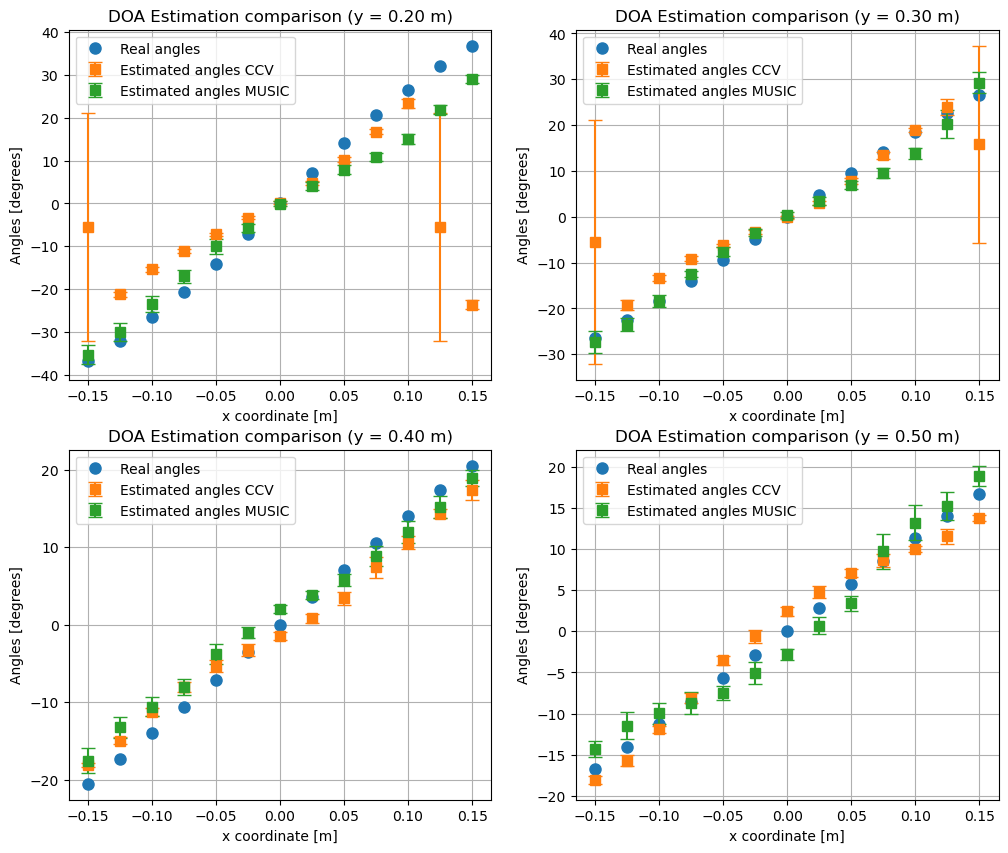

<Figure size 640x480 with 0 Axes>

In [18]:
plt.figure(figsize=(12,10))

plt.subplot(2,2,1)
plt.plot(x,theta_real_20, 'o', markersize=8, label='Real angles')
plt.errorbar(x, mean_ccv_20,
                 yerr=std_ccv_20,
                 fmt='s',
                 markersize=7,
                 capsize=5,
                 label='Estimated angles CCV')
plt.errorbar(x, mean_music_20,
                 yerr=std_music_20,
                 fmt='s',
                 markersize=7,
                 capsize=5,
                 label='Estimated angles MUSIC')
plt.legend()
plt.title("DOA Estimation comparison (y = 0.20 m)")
plt.xlabel("x coordinate [m]")
plt.ylabel("Angles [degrees]")
plt.grid()

plt.subplot(2,2,2)
plt.plot(x,theta_real_30, 'o', markersize=8, label='Real angles')
plt.errorbar(x, mean_ccv_30,
                 yerr=std_ccv_30,
                 fmt='s',
                 markersize=7,
                 capsize=5,
                 label='Estimated angles CCV')
plt.errorbar(x, mean_music_30,
                 yerr=std_music_30,
                 fmt='s',
                 markersize=7,
                 capsize=5,
                 label='Estimated angles MUSIC')
plt.legend()
plt.title("DOA Estimation comparison (y = 0.30 m)")
plt.xlabel("x coordinate [m]")
plt.ylabel("Angles [degrees]")
plt.grid()

plt.subplot(2,2,3)
plt.plot(x,theta_real_40, 'o', markersize=8, label='Real angles')
plt.errorbar(x, mean_ccv_40,
                 yerr=std_ccv_40,
                 fmt='s',
                 markersize=7,
                 capsize=5,
                 label='Estimated angles CCV')
plt.errorbar(x, mean_music_40,
                 yerr=std_music_40,
                 fmt='s',
                 markersize=7,
                 capsize=5,
                 label='Estimated angles MUSIC')
plt.legend()
plt.title("DOA Estimation comparison (y = 0.40 m)")
plt.xlabel("x coordinate [m]")
plt.ylabel("Angles [degrees]")
plt.grid()

plt.subplot(2,2,4)
plt.plot(x,theta_real_50, 'o', markersize=8, label='Real angles')
plt.errorbar(x, mean_ccv_50,
                 yerr=std_ccv_50,
                 fmt='s',
                 markersize=7,
                 capsize=5,
                 label='Estimated angles CCV')
plt.errorbar(x, mean_music_50,
                 yerr=std_music_50,
                 fmt='s',
                 markersize=7,
                 capsize=5,
                 label='Estimated angles MUSIC')
plt.legend()
plt.title("DOA Estimation comparison (y = 0.50 m)")
plt.xlabel("x coordinate [m]")
plt.ylabel("Angles [degrees]")
plt.grid()

plt.show()
plt.tight_layout()

## Conclusions

In this notebook, we implemented:

- The proposed CCV method
- The MUSIC algorithm for DOA estimation

Both methods were applied to experimental data acquired using a fiber optic sensing system.

This implementation demonstrates:

- Signal processing in Python
- Spectral analysis
- Direction of arrival estimation
- Reproducible scientific workflows

These results can be further used for:

- Error analysis
- Statistical evaluation
- Machine learning models for DOA estimation